In [1]:
%cd /u/jcai1/code/usefulxai/code/my_method

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import json
from modules.mhim import MHIM
import cv2
import random
import seaborn as sns
import os

/scratch/bdem/jcai1/bdem_usefulxai/code/my_method


## 第一步：读取特征和 patch 坐标（来自 .h5）

In [2]:
# 第一步：读取特征和 patch 坐标（来自 .h5）
import h5py
import torch

def load_features_and_coords(h5_path):
    with h5py.File(h5_path, 'r') as f:
        features = torch.from_numpy(f['features'][:])  # shape: [N, D]
        coords_ = f['coords'][:]  # shape: [N, 2], each is [x, y]
    print(f"Loaded {features.shape[0]} patches, feature dim: {features.shape[1]}, coords shape: {coords_.shape}")
    return features, coords_

features, coords = load_features_and_coords("/u/jcai1/code/usefulxai/data/camelyon16-clam/tumor_vs_normal_resnet_features/h5_files_labels/tumor_001.h5")
# features, coords = load_features_and_coords("/u/jcai1/code/usefulxai/data/camelyon16-clam/tumor_vs_normal_resnet_features/h5_files_labels/normal_001.h5")

x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
y_min, y_max = coords[:, 1].min(), coords[:, 1].max()

print(f"X range: {x_min} → {x_max}")
print(f"Y range: {y_min} → {y_max}")

Loaded 36710 patches, feature dim: 1024, coords shape: (36710, 2)
X range: 704 → 90880
Y range: 10432 → 162304


In [3]:
print(coords[:10])


[[ 17856 153856]
 [ 17856 154112]
 [ 18112 153600]
 [ 18112 153856]
 [ 18112 154112]
 [ 18112 154368]
 [ 18368 153344]
 [ 18368 153600]
 [ 18368 153856]
 [ 18368 154112]]


## 第二步：读取已训练好模型的attention score

In [4]:
# Attention for TransMIL
pure = MHIM(da_act='relu',baseline='selfattn').eval()
pure.requires_grad_(False)

pure_cpt = torch.load('/u/jcai1/code/usefulxai/paper_results/pure_model/transmil_0507_1818/fold_0_model_best_auc.pt',map_location='cpu')

pure.load_state_dict(pure_cpt['model'], strict=False)
pure.eval()
with torch.no_grad():
    _, attns = pure.forward_test(features.unsqueeze(0),return_attn=True)
    attn = attns[-1].mean(dim=1).squeeze(0) # Take last layer
    print(attn.shape)
attn_scores = attn.cpu().numpy()
print(attn_scores)


torch.Size([36710])
[2.9557270e-07 2.9576299e-07 2.9455714e-07 ... 4.0359382e-07 1.7569596e-07
 3.6158352e-07]


In [5]:
# 得到每个坐标的attention
attn_norm = (attn_scores - attn_scores.min()) / (attn_scores.max() - attn_scores.min() + 1e-6)
coords_attn = {
    tuple(coords[i]): float(attn_norm[i]) for i in range(len(coords))
}
print(coords_attn)
for i, (x, y) in enumerate(coords[:5]):
    print(coords_attn[(x,y)])

{(17856, 153856): 0.14967550337314606, (17856, 154112): 0.14968188107013702, (18112, 153600): 0.1496415138244629, (18112, 153856): 0.14963622391223907, (18112, 154112): 0.1496213972568512, (18112, 154368): 0.1497427225112915, (18368, 153344): 0.1495998352766037, (18368, 153600): 0.14977382123470306, (18368, 153856): 0.1496177613735199, (18368, 154112): 0.14973559975624084, (18624, 151296): 0.1496025174856186, (18624, 151552): 0.1498887836933136, (18624, 151808): 0.14959871768951416, (18624, 153088): 0.14964936673641205, (18624, 153344): 0.14960907399654388, (18624, 153600): 0.14964011311531067, (18624, 153856): 0.1496272087097168, (18624, 154112): 0.14966361224651337, (18880, 151296): 0.14982695877552032, (18880, 151552): 0.14973044395446777, (18880, 151808): 0.14960376918315887, (18880, 152064): 0.14977072179317474, (18880, 152320): 0.1496242731809616, (18880, 152576): 0.1496354043483734, (18880, 152832): 0.14964048564434052, (18880, 153088): 0.14972332119941711, (18880, 153344): 0.14

## 第三步：根据mask文件得到绘制区间（level0）

In [6]:
# region = (70144, 122624, 73472, 134656)  # 在 level=0 下的 region
region = (60144, 112624, 74216, 144400)
# region = (60144, 112624, 74216, 144400)
left, top, right, bottom = region
w, h = right - left, bottom - top

In [7]:
from openslide import OpenSlide
import numpy as np

def get_tumor_region_from_mask(mask_path, mask_level=8):
    mask_slide = OpenSlide(mask_path)
    print("Level dimensions of mask:", mask_slide.level_dimensions)
    dims = mask_slide.level_dimensions[mask_level]
    mask_img = mask_slide.read_region((0, 0), mask_level, dims).convert("L")
    mask_arr = np.array(mask_img)
    
    mask_h, mask_w = mask_arr.shape
    x_range = (0, mask_w - 1)
    y_range = (0, mask_h - 1)
    print(f"Full X range of mask (level 8): {x_range}")
    print(f"Full Y range of mask (level 8): {y_range}")

    coords_ = np.argwhere(mask_arr == 2)
    if len(coords_) == 0:
        print("No tumor (label==2) found in entire mask!")
        return None
    
    y_min, x_min = coords_.min(axis=0)
    y_max, x_max = coords_.max(axis=0)

    print(f"Tumor region in mask level {mask_level}: x=[{x_min}, {x_max}], y=[{y_min}, {y_max}]")
    
    # 映射回 level 0 坐标
    downsample = mask_slide.level_downsamples[mask_level]
    region = int(x_min * downsample), int(y_min * downsample), int(x_max * downsample), int(y_max * downsample)
    print("Suggested tumor region (level 0):", region)
    
    coords_ = np.argwhere(mask_arr == 1)
    if len(coords_) == 0:
        print("No normal (label==1) found in entire mask!")
        return None
    
    y_min, x_min = coords_.min(axis=0)
    y_max, x_max = coords_.max(axis=0)

    print(f"Normal region in mask level {mask_level}: x=[{x_min}, {x_max}], y=[{y_min}, {y_max}]")
    
    # 映射回 level 0 坐标
    downsample = mask_slide.level_downsamples[mask_level]
    region = int(x_min * downsample), int(y_min * downsample), int(x_max * downsample), int(y_max * downsample)
    print("Suggested normal region (level 0):", region)
    
get_tumor_region_from_mask("/u/jcai1/code/usefulxai/data/camelyon16/masks/tumor_001_mask.tif")

Level dimensions of mask: ((97792, 221184), (48896, 110592), (24448, 55296), (12224, 27648), (6112, 13824), (3056, 6912), (1528, 3456), (764, 1728), (382, 864))
Full X range of mask (level 8): (0, 381)
Full Y range of mask (level 8): (0, 863)
Tumor region in mask level 8: x=[274, 286], y=[479, 525]
Suggested tumor region (level 0): (70144, 122624, 73216, 134400)
Normal region in mask level 8: x=[3, 351], y=[57, 826]
Suggested normal region (level 0): (768, 14592, 89856, 211456)


## 第四步：在原图上绘制attention和groud-truth annotation轮廓

In [8]:
svs_path="/u/jcai1/code/usefulxai/data/camelyon16/images/tumor_001.tif"
slide = OpenSlide(svs_path)
print(slide.level_dimensions)

((97792, 221184), (48896, 110592), (24448, 55296), (12224, 27648), (6112, 13824), (3056, 6912), (1528, 3456), (764, 1728), (382, 864), (191, 432))


In [9]:
# region = (70144, 122624, 73472, 134656)  # 在 level=0 下的 region
region = (60144, 112624, 74216, 144400)
# region = (60144, 112624, 74216, 144400)
left, top, right, bottom = region
w, h = right - left, bottom - top

In [10]:
base_img = np.array(slide.read_region((left, top), 0, (w, h)).convert("RGB"))
print(base_img.shape)

(31776, 14072, 3)


In [11]:
mask_path="/u/jcai1/code/usefulxai/data/camelyon16/masks/tumor_001_mask.tif"
mask_slide = OpenSlide(mask_path) 

In [12]:
level = mask_slide.level_count - 1
print(level)

8


In [13]:
mask_img = mask_slide.read_region((left, top), 8, (w, h)).convert("L")
mask_arr = np.array(mask_img)
print(mask_arr.shape)

(31776, 14072)


In [14]:
values, counts = np.unique(mask_arr, return_counts=True)

# 打印每个像素值及其出现的次数
for val, cnt in zip(values, counts):
    print(f"Value {val}: {cnt} pixels")

Value 0: 447139509 pixels
Value 1: 12232 pixels
Value 2: 131 pixels


[INFO] Attn min: 0.0 max: 0.96653026 attn_norm shape (36710,)
[INFO] Partial mask shape: (31776, 14072), unique labels: [0 1 2]
Found 12232 coordinates with value 1:
0 0
0 256
0 512
0 768
0 1024
0 1280
0 1536
0 1792
0 2048
0 2304
0 2560
0 2816
0 3072
0 3328
0 3584
0 3840
0 4096
0 4352
0 4608
0 4864
0 5120
0 5376
0 5632
0 5888
0 6144
0 6400
0 6656
0 6912
0 7168
0 7424
0 7680
0 7936
0 8192
0 8448
0 8704
0 8960
0 9216
0 9472
0 9728
0 9984
0 10240
0 10496
0 10752
0 11008
0 11264
0 11520
0 11776
0 12032
0 12288
0 12544
0 12800
0 13056
0 13312
0 13568
0 13824
0 14080
0 14336
0 14592
0 14848
0 15104
0 15360
0 15616
0 15872
0 16128
0 17664
0 17920
0 18176
0 18432
0 18688
0 18944
0 19200
0 19456
0 19712
0 19968
0 20224
0 20480
0 20736
0 20992
0 21248
0 21504
0 21760
0 22016
0 22272
0 22528
0 22784
0 23040
0 23296
0 23552
256 0
256 256
256 512
256 768
256 1024
256 1280
256 1536
256 1792
256 2048
256 2304
256 2560
256 2816
256 3072
256 3328
256 3584
256 3840
256 4096
256 4352
256 4608
256 4864
25

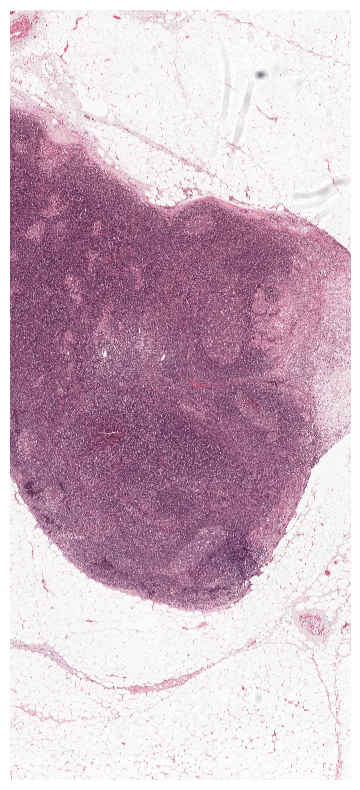

In [ ]:
import openslide
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_attention_on_region(_base_img, coords_, coords_attn_, 
                             patch_size=256, level=0, alpha=0.5,
                             region=None,
                             _mask_arr=None, mask_level=8):  # <<< 新增参数
    # * -------------- 读取原图片对应region部分（level0） --------------

    heatmap = _base_img.copy()
    coords_set_ = set(map(tuple, coords_))

    print("[INFO] Attn min:", attn_norm.min(), "max:", attn_norm.max(),"attn_norm shape",attn_norm.shape)

    # * -------------- 加载mask并绘制轮廓 --------------
    if _mask_arr is not None:
        
        print(f"[INFO] Partial mask shape: {_mask_arr.shape}, unique labels: {np.unique(_mask_arr)}")
        
        # 提取 normal 区域并绘制边界
        normal_mask = (_mask_arr == 1).astype(np.uint8)
        # count = np.sum(normal_mask == 1) # tumor的mask只存在于图片左上角
        temp = np.argwhere(normal_mask == 1)
        print(f"Found {len(temp)} coordinates with value 1:")
        for t in temp:
            rel_y, rel_x = t[0]*256, t[1]*256
            print(rel_y, rel_x)
            color =  (0, 255, 0) # 绿色
            # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图
            cv2.rectangle(
                img=heatmap,                          # 要画的图像（NumPy array，通常是 RGB）
                pt1=(rel_x, rel_y),                   # 左上角坐标
                pt2=(rel_x + 256, rel_y + 256), # 右下角坐标
                color=color,                          # 矩形颜色（B, G, R）格式
                thickness=-1                          # 填充整个矩形（如果是 2 表示边框宽度为 2）
            )
        print("aaa")
        # 提取 tumor 区域并绘制边界（仅 label==2）
        # tumor_mask = (_mask_arr == 2).astype(np.uint8)
        # count = np.sum(tumor_mask == 1) # tumor的mask只存在于图片左上角
        # temp = np.argwhere(tumor_mask == 1)
        # print(f"Found {len(temp)} coordinates with value 1:")
        # for t in temp:
        #     rel_y, rel_x = t[0]*256, t[1]*256

        #     color =  (0, 0, 255) # 蓝色
        #     # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图
        #     cv2.rectangle(
        #         img=heatmap,                          # 要画的图像（NumPy array，通常是 RGB）
        #         pt1=(rel_x, rel_y),                   # 左上角坐标
        #         pt2=(rel_x + 512, rel_y + 512), # 右下角坐标
        #         color=color,                          # 矩形颜色（B, G, R）格式
        #         thickness=-1                          # 填充整个矩形（如果是 2 表示边框宽度为 2）
        #     )
            
    blended = cv2.addWeighted(heatmap, alpha, base_img, 1 - alpha, 0)

                
    # ------------------------------------------------

    # show image
    plt.figure(figsize=(10, 10))
    plt.imshow(blended)
    plt.axis("off")
    # plt.title("Attention Heatmap + Tumor Mask")
    plt.show()
    

show_attention_on_region(
    _base_img=base_img,
    coords_=coords,
    coords_attn_=coords_attn,
    _mask_arr=mask_arr)


[INFO] Attn min: 0.0 max: 0.96653026 attn_norm shape (36710,)
9616 9552
6032 20304
8080 19792
11920 19024
144 592
12432 18768
3984 9808
2704 4176
8336 18768
1168 14416
7056 13136
5520 13392
12944 11856
9360 22608
144 7760
2192 7248
2448 17232
4496 16720
10384 15440
5520 20560
1168 592
5008 9808
3472 10064
10896 8528
9360 8784
1936 20304
5776 19536
11408 8272
7824 19024
11920 12368
2128 27024
13968 11856
12432 12112
10384 22608
8848 22864
2448 3408
912 13648
8336 12112
3472 17232
9360 15952
11408 15440
9872 15696
144 1104
2448 10576
4496 10064
2960 10320
912 20816
10384 8784
8336 19280
6800 19536
1424 20560
12688 18256
9872 22864
1936 13648
5776 12880
7824 12368
11664 11600
4240 23120
10128 21840
2960 17488
8848 16208
912 6992
6800 5712
3216 16464
9360 9296
5776 20048
11408 8784
9872 9040
7824 19536
11664 18768
6288 19792
12176 18512
2448 3920
912 14160
6800 12880
1424 13904
12688 11600
7312 12624
5264 23120
9104 22352
3728 23376
11152 21840
9872 16208
1936 6992
400 7248
4240 16464
1012

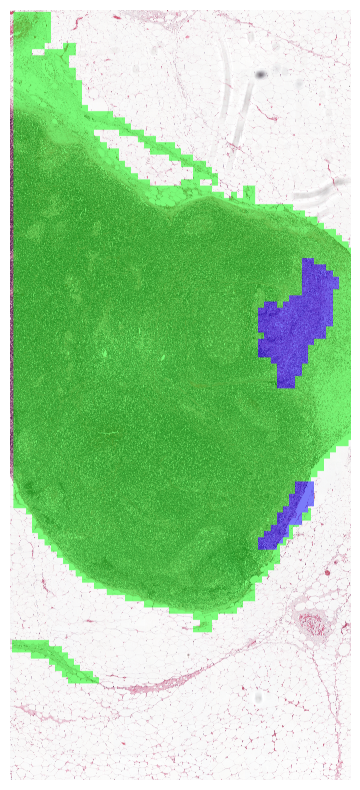

In [19]:
import openslide
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_attention_on_region(_base_img, coords_, coords_attn_, 
                             patch_size=256, level=0, alpha=0.5,
                             region=None,
                             _mask_arr=None, mask_level=8):  # <<< 新增参数
    # * -------------- 读取原图片对应region部分（level0） --------------

    heatmap = _base_img.copy()
    coords_set_ = set(map(tuple, coords_))

    print("[INFO] Attn min:", attn_norm.min(), "max:", attn_norm.max(),"attn_norm shape",attn_norm.shape)

    # * -------------- 加载mask并绘制轮廓 --------------
    if _mask_arr is not None:
        
        # print(f"[INFO] Partial mask shape: {_mask_arr.shape}, unique labels: {np.unique(_mask_arr)}")
        
        # # 提取 normal 区域并绘制边界
        normal_mask = (_mask_arr == 1).astype(np.uint8)
        # # count = np.sum(normal_mask == 1) # tumor的mask只存在于图片左上角
        temp = np.argwhere(normal_mask == 1)
        
        for (x, y) in coords_set_:
            x = int(x)
            y=int(y)
            # print(x,y) # 56960 113280 ; 56960 113536
            if not (left <= x < right and top <= y < bottom):
                continue  # skip patches outside region
            rel_x_coord = int(x - left)
            rel_y_coord = int(y - top)
            t = (rel_y_coord // 256, rel_x_coord // 256)
            if t in temp:
                print(rel_x_coord, rel_y_coord)
                color =  (0, 255, 0) # 绿色
                # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图
                cv2.rectangle(
                    img=heatmap,                          # 要画的图像（NumPy array，通常是 RGB）
                    pt1=(rel_x_coord, rel_y_coord),                   # 左上角坐标
                    pt2=(rel_x_coord + 256, rel_y_coord + 256), # 右下角坐标
                    color=color,                          # 矩形颜色（B, G, R）格式
                    thickness=-1                          # 填充整个矩形（如果是 2 表示边框宽度为 2）
                )
        print("aaa")
        
        # 提取 tumor 区域并绘制边界（仅 label==2）
        tumor_mask = (_mask_arr == 2).astype(np.uint8)
        count = np.sum(tumor_mask == 1) # tumor的mask只存在于图片左上角
        temp = np.argwhere(tumor_mask == 1)
        print(f"Found {len(temp)} coordinates with value 1:")
        for t in temp:
            rel_y, rel_x = t[0]*256, t[1]*256

            color =  (0, 0, 255) # 蓝色
            # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图
            cv2.rectangle(
                img=heatmap,                          # 要画的图像（NumPy array，通常是 RGB）
                pt1=(rel_x, rel_y),                   # 左上角坐标
                pt2=(rel_x + 512, rel_y + 512), # 右下角坐标
                color=color,                          # 矩形颜色（B, G, R）格式
                thickness=-1                          # 填充整个矩形（如果是 2 表示边框宽度为 2）
            )
        

            
    blended = cv2.addWeighted(heatmap, alpha, base_img, 1 - alpha, 0)

                
    # ------------------------------------------------

    # show image
    plt.figure(figsize=(10, 10))
    plt.imshow(blended)
    plt.axis("off")
    # plt.title("Attention Heatmap + Tumor Mask")
    plt.show()
    

show_attention_on_region(
    _base_img=base_img,
    coords_=coords,
    coords_attn_=coords_attn,
    _mask_arr=mask_arr)